In [1]:
%pip install opencv-python tf-keras-vis seaborn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Variables de control


In [2]:
# Si False no entrenara el modelo ni ejecutar el codigo relacionado (Desde el paso 4 al 6)
traing_model_from_zero = False
# Si True entrenara el modelo con transfer learining se ejecutar nuevamente.
# Si False usara el peso guardado en la carpeta raiz con el nombre 
train_transfer_model_again = False 



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from tensorflow.keras import backend as K
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import load_model as keras_load_model
import kagglehub
import random
import cv2

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import callbacks

from tensorflow.keras import Model, Input
from tf_keras_vis.utils.scores import  Score
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.saliency import Saliency


from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.cm as cm


/Users/allan/Documents/maestria/deep learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

def plot_training_history(history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Loss
        ax1.plot(history.history['loss'], label='Train Loss')
        ax1.plot(history.history['val_loss'], label='Val Loss')
        ax1.set_title('Pérdida durante el entrenamiento')
        ax1.set_xlabel('Época')
        ax1.set_ylabel('Pérdida')
        ax1.legend()
        ax1.grid(True)

        # Accuracy
        ax2.plot(history.history['accuracy'], label='Train Acc')
        ax2.plot(history.history['val_accuracy'], label='Val Acc')
        ax2.set_title('Precisión durante el entrenamiento')
        ax2.set_xlabel('Época')
        ax2.set_ylabel('Precisión')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()


def load_model(ruta_modelo='brain_tumor_vgg16_model'):
    import os
    
    if os.path.exists(ruta_modelo) or os.path.exists(ruta_modelo + '.h5'):
        print(f"Cargando modelo desde: {ruta_modelo}")
        model = keras_load_model(ruta_modelo)
        print("Modelo cargado exitosamente!")
        return model
    else:
        print(f"Error: No se encontró el modelo en '{ruta_modelo}'")
        print("Debes entrenar el modelo primero o verificar la ruta.")
        return None

def show_images(image_titles, images, cmap='viridis'):
    f, ax = plt.subplots(nrows=1, ncols=len(images), figsize=(12, 4))
    for i, title in enumerate(image_titles):
        ax[i].set_title(title, fontsize=16)
        ax[i].imshow(images[i], cmap=cmap)
        ax[i].axis('off')
    plt.tight_layout()
    plt.show()

def show_images_with_heatmap(image_titles, images, cam=None, cmap='viridis'):
    n_images = len(image_titles)
    ncols = 5
    nrows = (n_images + ncols - 1) // ncols
    
    f, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 3))
    
    # Aplanar el array de ejes para facilitar la iteración
    if nrows == 1:
        ax = ax.reshape(1, -1)
    
    for i, title in enumerate(image_titles):
        row = i // ncols
        col = i % ncols
        if(cam is not None):
            heatmap = np.uint8(cm.jet(cam[i])[..., :3] * 255)
        ax[row, col].set_title(title, fontsize=12)
        ax[row, col].imshow(images[i], cmap=cmap)
        if(cam is not None):
            ax[row, col].imshow(heatmap, cmap='jet', alpha=0.5)  # overlay
        ax[row, col].axis('off')
    
    # Ocultar ejes vacíos si los hay
    for i in range(n_images, nrows * ncols):
        row = i // ncols
        col = i % ncols
        ax[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

def load_image(path, target_size=(224, 224)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0
    return img

## 1. Descargar dataset

In [5]:


# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

tumor_path = path + '/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor'
healthy_path = path + '/Brain Tumor Data Set/Brain Tumor Data Set/Healthy'

In [6]:
images_path = []
clases = [] #0 healty , 1 Tumor

for filename in os.listdir(tumor_path):
    images_path.append(tumor_path + '/' + filename)
    clases.append(1)
for filename in os.listdir(healthy_path):
    images_path.append(healthy_path + '/' + filename)
    clases.append(0)

## 2. EDA

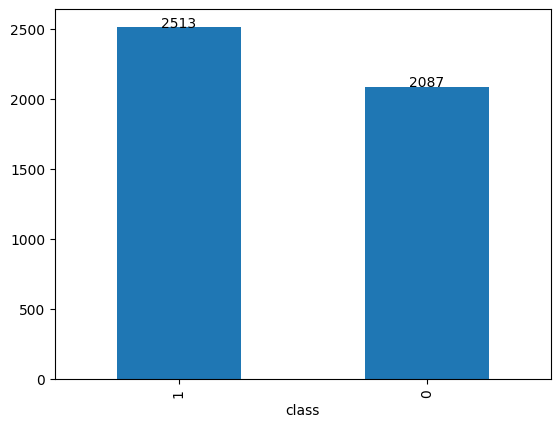

In [7]:
# EDA Clases


df = pd.DataFrame()
df['class'] = clases
# bar plot
df['class'].value_counts().plot(kind='bar')
# set labels to each bar
for i in df['class'].value_counts().index:
    plt.text(x=(i +1) % 2, y=df['class'].value_counts()[i ], s=df['class'].value_counts()[i], ha='center')

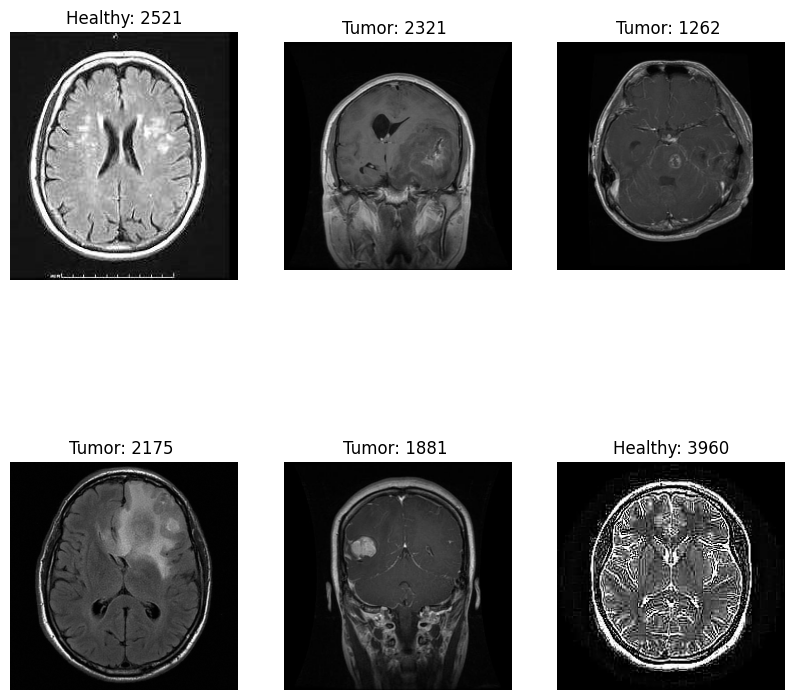

In [8]:
# Show 3 images with tumor and 3 heatlty in a grid


random.seed(60)

ax, fig = plt.subplots(2, 3, figsize=(10, 10))
for i in range(2):
    for j in range(3):
        idx = random.randint(0, len(images_path))
        img = cv2
        img = cv2.imread(images_path[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        fig[i, j].imshow(img)
        fig[i, j].axis('off')
        if clases[idx] == 1:
            fig[i, j].set_title(f'Tumor: {idx} ')
        else:
            fig[i, j].set_title(f'Healthy: {idx}')
plt.show()

In [9]:
img_example  = cv2.imread(images_path[60])
img_example2  = cv2.imread(images_path[10])



In [10]:
print(img_example.shape)
print(img_example2.shape)

(512, 512, 3)
(512, 512, 3)


In [11]:
print(img_example.dtype)
print(img_example2.dtype)
# El maximo valor es de 255 porque esta e unit8

uint8
uint8


In [12]:
## 3. Preparación de datos

In [13]:
# División del dataset
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    images_path, clases, test_size=0.2, random_state=42, stratify=clases
)

print(f'Train samples: {len(X_train_paths)}')
print(f'Test samples: {len(X_test_paths)}')

Train samples: 3680
Test samples: 920


In [14]:
def load_and_preprocess_images(image_paths, labels, img_size=(224, 224)):
    X = []
    y = []
    for path, label in zip(image_paths, labels):
        img = cv2.imread(path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            img = img / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

# Cargar y preprocesar imágenes
X_train, y_train = load_and_preprocess_images(X_train_paths, y_train)
X_test, y_test = load_and_preprocess_images(X_test_paths, y_test)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (3680, 224, 224, 3)
X_test shape: (920, 224, 224, 3)


## 4. Modelo CNN (saltarse este paso hasta el paso 7)

In [15]:
if(not traing_model_from_zero):
    model = load_model('tummor_model_from_zero.h5')


Cargando modelo desde: tummor_model_from_zero.h5


Modelo cargado exitosamente!


In [16]:
if(traing_model_from_zero):
    def create_cnn_model(input_shape=(224, 224, 3), num_classes=2):
        model = Sequential([
            Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Conv2D(64, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Conv2D(128, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Conv2D(256, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Conv2D(512, (3, 3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Flatten(),
            Dense(1024, activation='relu'),
            Dropout(0.5),
            Dense(num_classes, activation='softmax')
        ])
        return model

    model = create_cnn_model()
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

/Users/allan/Documents/maestria/deep learning/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
if(traing_model_from_zero):
    model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,682,818 (56.01 MB)

 Trainable params: 14,680,834 (56.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

## 5. Entrenamiento

In [18]:
if(traing_model_from_zero):

    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1
    )

    epochs = 20
    batch_size = 32
    seed=42

    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=batch_size, seed=seed),
        epochs=epochs,
        validation_data=(X_test, y_test),
        steps_per_epoch=len(X_train) // batch_size,
        verbose=1
    )

/Users/allan/Documents/maestria/deep learning/.venv/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 89s 749ms/step - accuracy: 0.6679 - loss: 3.4981 - val_accuracy: 0.5467 - val_loss: 2.7804
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 92s 797ms/step - accuracy: 0.7563 - loss: 0.5596 - val_accuracy: 0.5359 - val_loss: 2.0847
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 102s 883ms/step - accuracy: 0.7981 - loss: 0.4486 - val_accuracy: 0.7076 - val_loss: 0.7673
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 97s 839ms/step - accuracy: 0.8283 - loss: 0.4141 - val_accuracy: 0.7000 - val_loss: 1.9371
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 96s 830ms/step - accuracy: 0.8410 - loss: 0.3753 - val_accuracy: 0.8935 - val_loss: 0.2856
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 715ms/step - accuracy: 0.8535 - loss: 0.3557 - val_accuracy: 0.8228 - val_loss: 0.4030
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 712ms/step - accuracy: 0.8726 - loss: 0.3061 - val_accuracy: 0.7337 - val_loss: 0.8117
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 711ms/step - accuracy: 0.8758 - loss: 

In [19]:
if(traing_model_from_zero):
    model.save('tummor_model_from_zero.h5')

## 6. Visualización de resultados

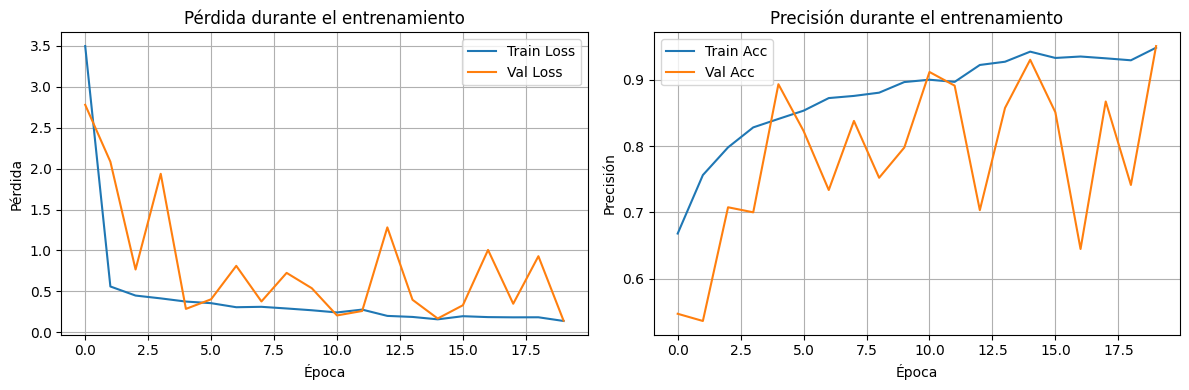

In [ ]:
if(traing_model_from_zero):
    plot_training_history(history)

In [ ]:

# Evaluación final
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Precisión en test: {test_accuracy:.4f}')
print(f'Pérdida en test: {test_loss:.4f}')

Precisión en test: 0.9511
Pérdida en test: 0.1413


29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 215ms/step


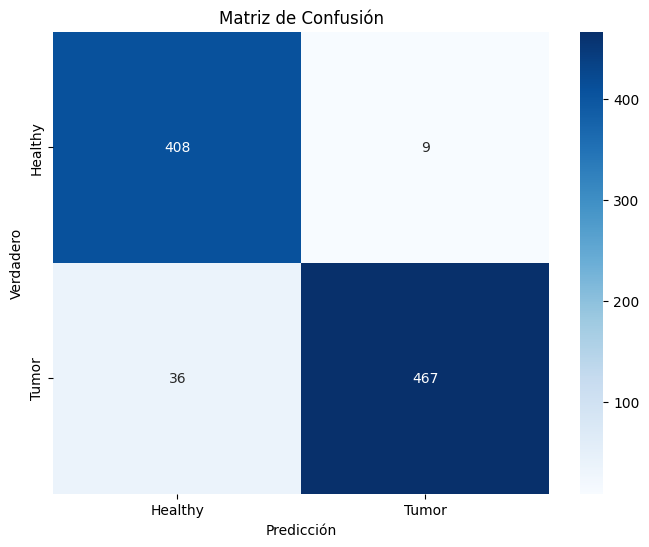


Reporte de clasificación:
              precision    recall  f1-score   support

     Healthy       0.92      0.98      0.95       417
       Tumor       0.98      0.93      0.95       503

    accuracy                           0.95       920
   macro avg       0.95      0.95      0.95       920
weighted avg       0.95      0.95      0.95       920



In [16]:


# Predicciones y matriz de confusión


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Tumor'],
            yticklabels=['Healthy', 'Tumor'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Reporte de clasificación
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_classes,
                        target_names=['Healthy', 'Tumor']))

In [17]:

metrics_from_zero = {
    'Modelo': 'From Zero',
    'Accuracy': accuracy_score(y_test, y_pred_classes),
    'Precision': precision_score(y_test, y_pred_classes, average='weighted'),
    'Recall': recall_score(y_test, y_pred_classes, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_classes, average='weighted')
}

## Paso 7. Transfer learning

In [18]:

# Reiniciar el backend para que las ejecuciones anteriores no interfieran
K.clear_session()

In [19]:
if not train_transfer_model_again:
   model_transfer = load_model('brain_tumor_vgg16_model.h5')

Cargando modelo desde: brain_tumor_vgg16_model.h5
Modelo cargado exitosamente!


In [ ]:
if(train_transfer_model_again) :


    # Cargamos el modelo VGG16 preentrenado, excluyendo las capas superiores (top=False)
    # Recuerde que las capas superiores son las que definen el tipo de problema a solucionar
    # Como nuestro problema es de 10 categorias (10 digitos), agregaremos nuestras propias capas superiores
    vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    vgg16_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
if(train_transfer_model_again) :

    vgg16_base.trainable = False

    # Crear modelo funcional equivalente

    inputs = Input(shape=(224, 224, 3))
    x = vgg16_base(inputs)
    x = Flatten()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(2, activation='softmax')(x)

    model_transfer = Model(inputs=inputs, outputs=outputs)
    

In [ ]:
if(train_transfer_model_again) :

    #  !Importante: en este experimento no haremos aumento de datos para ver el comportamiento

    model_transfer.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history_transfer = model_transfer.fit(X_train, y_train, epochs=5,
                        batch_size=64, validation_data=(X_test, y_test))

Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 333s 6s/step - accuracy: 0.7671 - loss: 0.5680 - val_accuracy: 0.9174 - val_loss: 0.2199
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 329s 6s/step - accuracy: 0.9158 - loss: 0.2015 - val_accuracy: 0.9467 - val_loss: 0.1545
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 330s 6s/step - accuracy: 0.9476 - loss: 0.1455 - val_accuracy: 0.9717 - val_loss: 0.1174
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 328s 6s/step - accuracy: 0.9611 - loss: 0.1166 - val_accuracy: 0.9750 - val_loss: 0.0983
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 331s 6s/step - accuracy: 0.9701 - loss: 0.0896 - val_accuracy: 0.9717 - val_loss: 0.0914


In [30]:
if(train_transfer_model_again) :
    model_transfer.save('brain_tumor_vgg16_model.h5')
    print("Modelo guardado exitosamente como 'brain_tumor_vgg16_model' (formato SavedModel)")

Modelo guardado exitosamente como 'brain_tumor_vgg16_model' (formato SavedModel)


### Paso 7.1: visualizacion  evaluacion

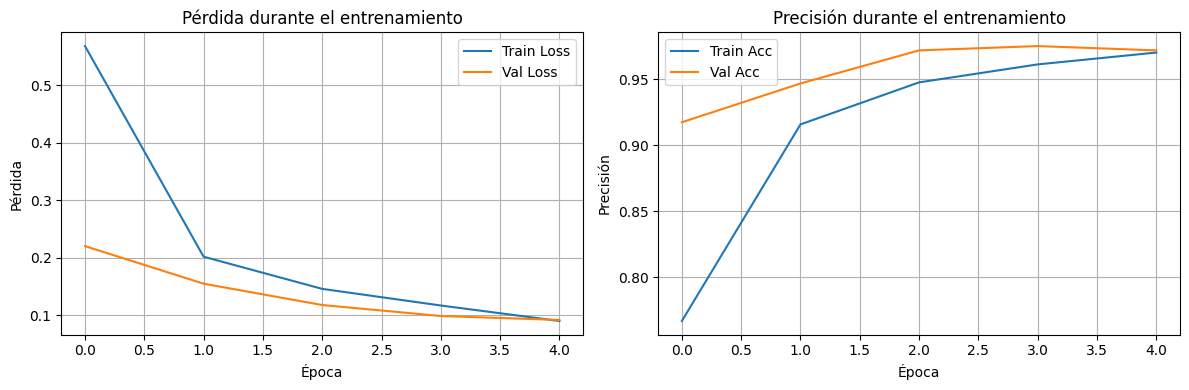

In [ ]:


if(train_transfer_model_again) :
    plot_training_history(history_transfer)

In [32]:
# Evaluación final
test_loss, test_accuracy = model_transfer.evaluate(X_test, y_test, verbose=0)
print(f'Precisión en test: {test_accuracy:.4f}')
print(f'Pérdida en test: {test_loss:.4f}')

Precisión en test: 0.9717
Pérdida en test: 0.0914


29/29 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step


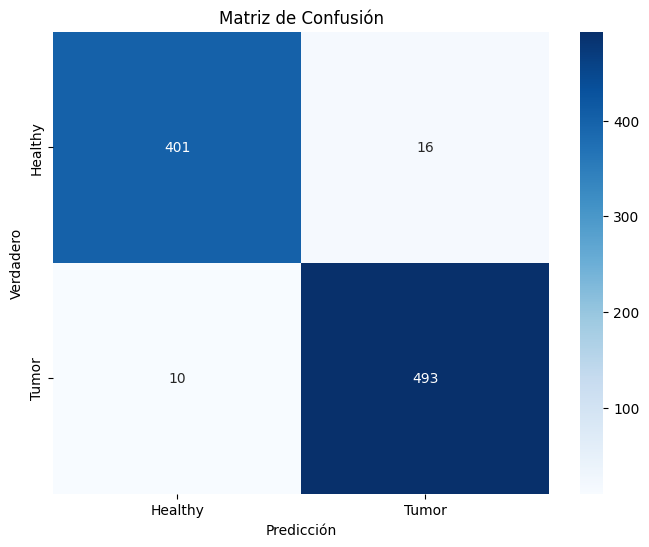


Reporte de clasificación:
              precision    recall  f1-score   support

     Healthy       0.98      0.96      0.97       417
       Tumor       0.97      0.98      0.97       503

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920



In [20]:
# Predicciones y matriz de confusión


y_pred = model_transfer.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Tumor'],
            yticklabels=['Healthy', 'Tumor'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Reporte de clasificación
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_classes,
                          target_names=['Healthy', 'Tumor']))

In [21]:


metrics_transfer = {
    'Modelo': 'Transfer Learning',
    'Accuracy': accuracy_score(y_test, y_pred_classes),
    'Precision': precision_score(y_test, y_pred_classes, average='weighted'),
    'Recall': recall_score(y_test, y_pred_classes, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_classes, average='weighted')
}

## Paso 8. Explicabilidad Transfermlearning


In [ ]:

tumor_image = load_image(images_path[2175])
healthy_image = load_image(images_path[3960])

In [38]:
class PredictedClassScore(Score):
    def __call__(self, model_output):
        # Escoger la clase predicha (máxima probabilidad)
        class_indices = tf.argmax(model_output, axis=1)
        indices = tf.stack([tf.range(tf.shape(model_output)[0], dtype=tf.int64), class_indices], axis=1)
        return tf.gather_nd(model_output, indices)

In [ ]:

def copy_model(model, layer_initial_weights = 1,input_shape=(224, 224, 3)):
    # Crear un modelo funcional completamente nuevo
    inputs = tf.keras.Input(shape=input_shape)

    # Crear VGG16 base funcional
    vgg16_new = VGG16(weights=None, include_top=False, input_tensor=inputs)

    # Copiar pesos de VGG16
    vgg16_new.set_weights(model.layers[layer_initial_weights].get_weights())

    # Continuar con las capas superiores
    x = tf.keras.layers.Flatten()(vgg16_new.output)
    x = tf.keras.layers.Dropout(0.5)(x, training=False)
    outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

    functional_model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Copiar pesos de la última capa densa
    functional_model.layers[-1].set_weights(model.layers[-1].get_weights())
    return functional_model

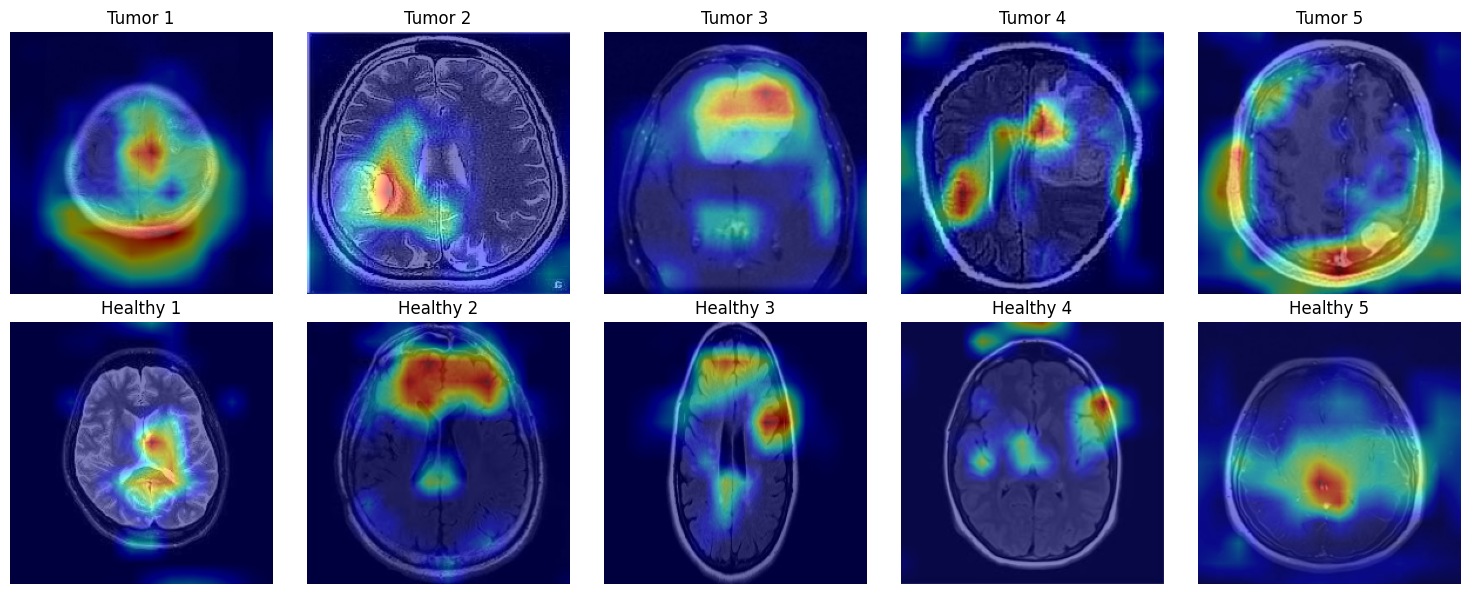

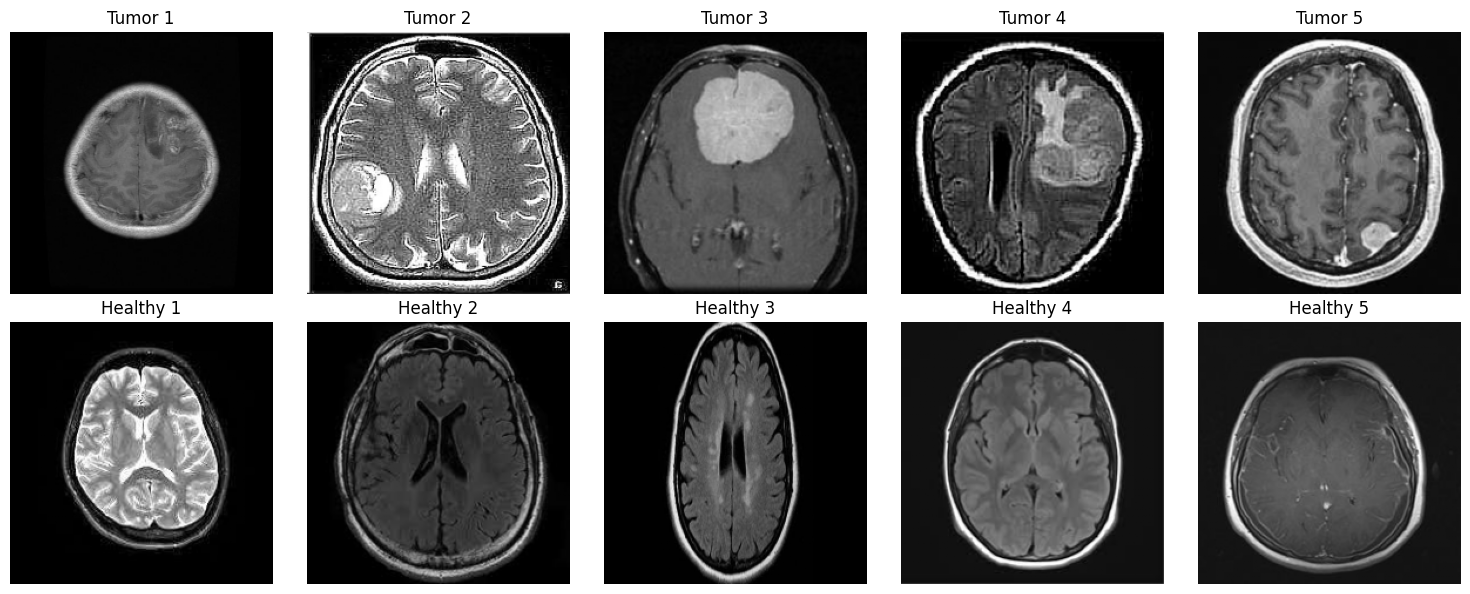

In [ ]:


tumor_indices = [i for i, label in enumerate(clases) if label == 1][:5]
healthy_indices = [i for i, label in enumerate(clases) if label == 0][:5]

# Cargar las imágenes
tumor_images = [load_image(images_path[i]) for i in tumor_indices]
healthy_images = [load_image(images_path[i]) for i in healthy_indices]

# Combinar todas las imágenes
all_images = tumor_images + healthy_images
image_titles = [f'Tumor {i+1}' for i in range(5)] + [f'Healthy {i+1}' for i in range(5)]
images = np.array(all_images)

# Preparar las imágenes como entrada para VGG16
X = images.copy()
X = np.array(X * 255, dtype=np.float32)
X = tf.keras.applications.vgg16.preprocess_input(X)

functional_model = copy_model(model_transfer)

# Usar ReplaceToLinear para cambiar softmax a linear
replace2linear = ReplaceToLinear()

# Create GradCAM object
gradcam = Gradcam(functional_model, model_modifier=replace2linear)

score = PredictedClassScore()

# Crear el mapa de calor con GradCAM
cam = gradcam(score, X, penultimate_layer=-1)

# Mostrar imágenes
show_images_with_heatmap(image_titles, images, cam, cmap='jet')

show_images_with_heatmap(image_titles, images, cmap='jet')

/Users/allan/Documents/maestria/deep learning/.venv/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_24
Received: inputs=['Tensor(shape=(10, 224, 224, 3))']
  warnings.warn(msg)


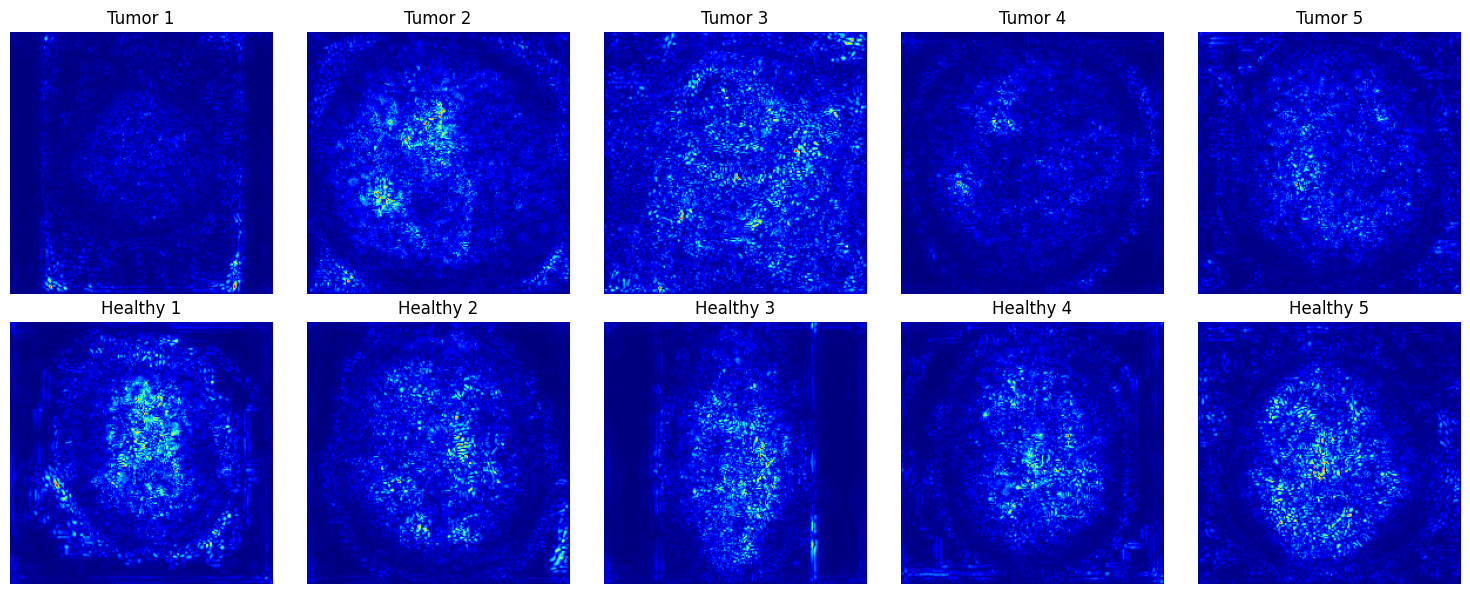

In [ ]:

# Crear un objeto de saliencia.
saliency = Saliency(functional_model, model_modifier=replace2linear, clone=True)

# Generar el mapa de saliencia
saliency_map = saliency(score, X)

# Mostrar imágenes
show_images_with_heatmap(image_titles, saliency_map, cmap='jet')

## Paso 9: Comparando modelos
Se grafica y compara las metricas de accuracy, F1 y recall

In [22]:

# Unificar con pandas
list_metrics = []
list_metrics.append(metrics_from_zero)
list_metrics.append(metrics_transfer)

df_comparison = pd.DataFrame(list_metrics)
print("\n=== Comparación de Todos los Modelos ===")
print(df_comparison.to_string(index=False))


=== Comparación de Todos los Modelos ===
           Modelo  Accuracy  Precision   Recall  F1-Score
        From Zero  0.951087   0.952912 0.951087  0.951179
Transfer Learning  0.971739   0.971785 0.971739  0.971721


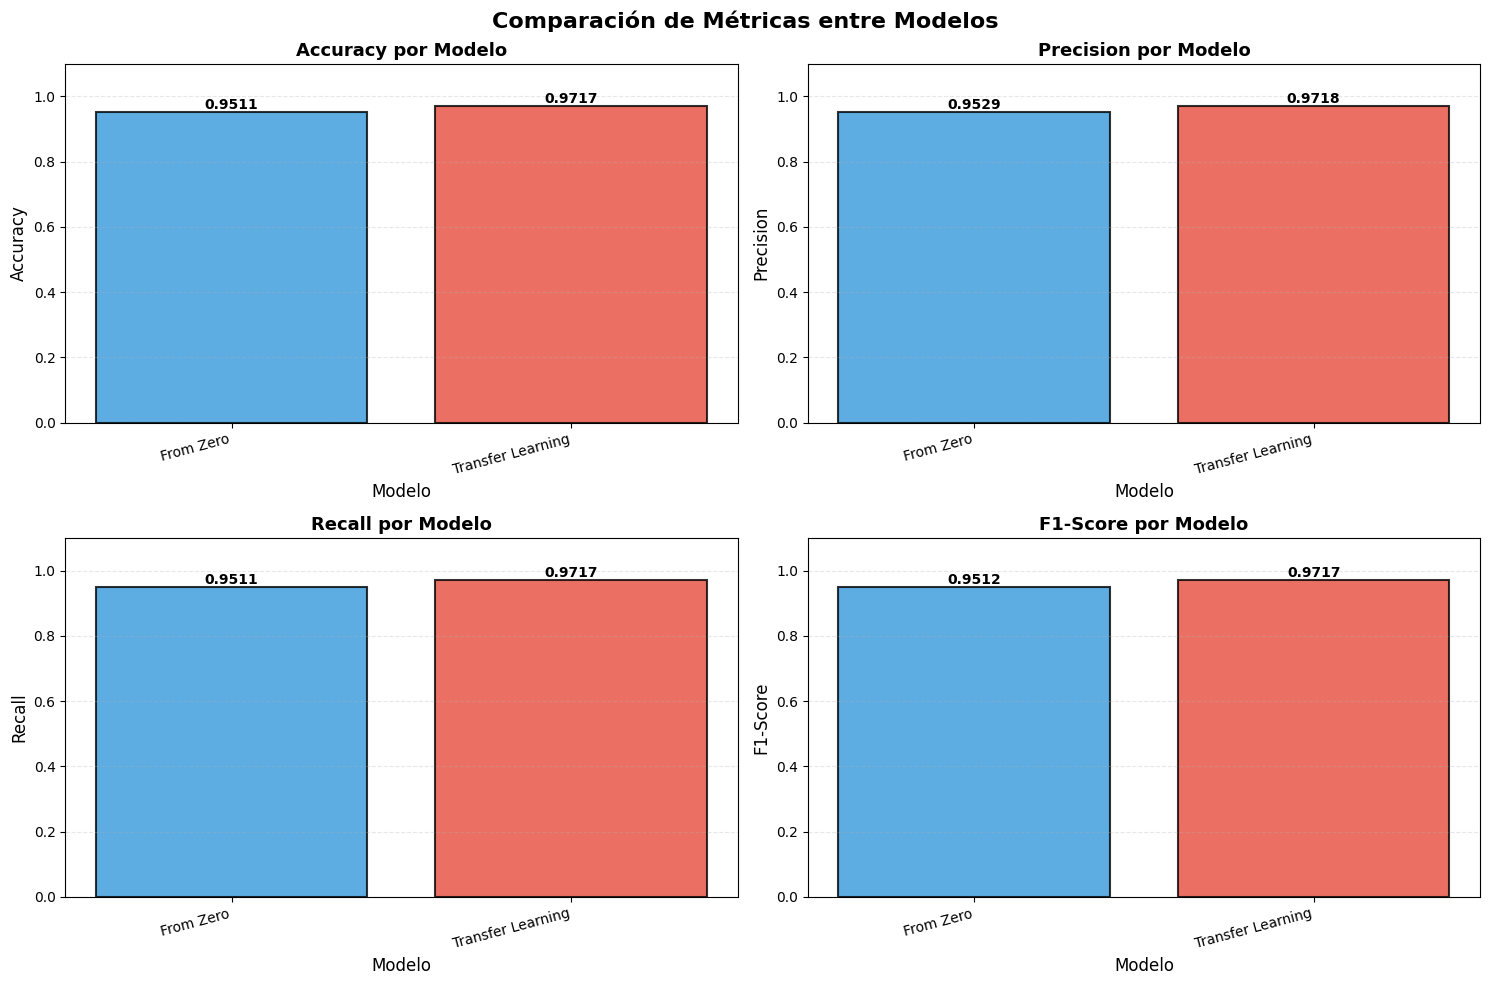

In [23]:
# Visualización: Diagrama de barras comparando los modelos

# Configurar el gráfico
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparación de Métricas entre Modelos', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Graficar cada métrica
for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    x = np.arange(len(df_comparison['Modelo']))
    values = df_comparison[metric]
    
    bars = ax.bar(x, values, color=colors[:len(df_comparison)], alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Añadir valores sobre las barras
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Modelo', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} por Modelo', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_comparison['Modelo'], rotation=15, ha='right')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

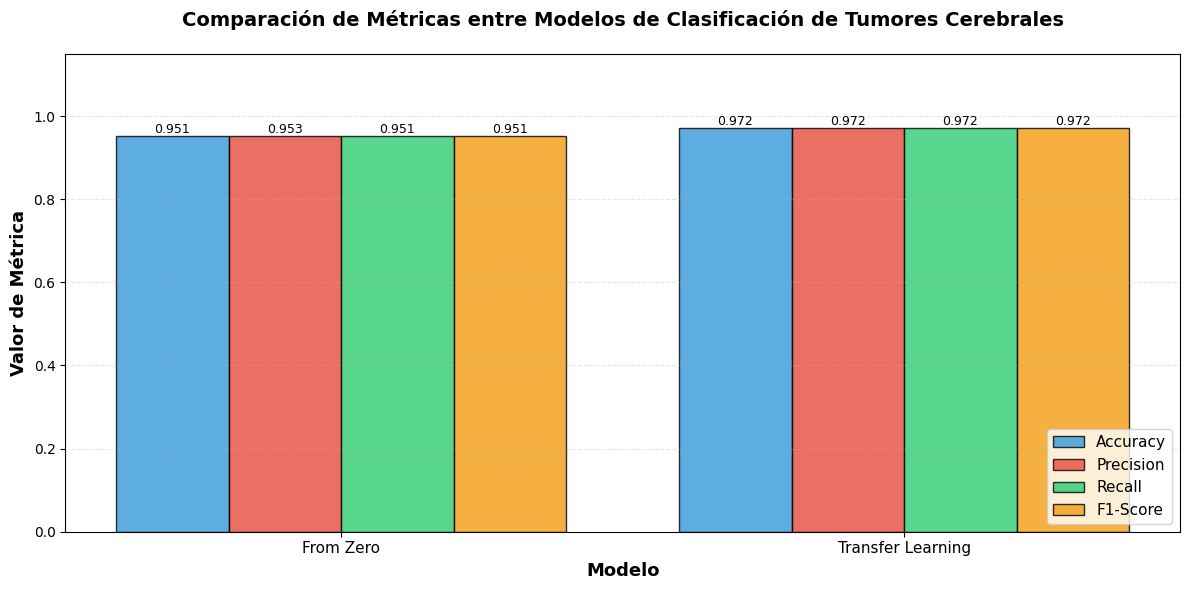

In [24]:
# Gráfico de barras agrupadas - Todas las métricas juntas
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_comparison['Modelo']))
width = 0.2

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_metrics = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, metric in enumerate(metrics_to_plot):
    offset = width * (i - 1.5)
    bars = ax.bar(x + offset, df_comparison[metric], width, 
                   label=metric, color=colors_metrics[i], alpha=0.8, edgecolor='black')
    
    # Añadir valores sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, rotation=0)

ax.set_xlabel('Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor de Métrica', fontsize=13, fontweight='bold')
ax.set_title('Comparación de Métricas entre Modelos de Clasificación de Tumores Cerebrales', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Modelo'], fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0, 1.15])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()